<a href="https://colab.research.google.com/github/PraneelUJ/IntraDay_VWAP_Algorithm/blob/main/traditional_vwap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Intraday VWAP Sell Execution

This notebook answers a practical execution question: **how should an order equal to 10% of a stock's daily market volume be sold during one trading day?**

It downloads intraday data from `yfinance`, builds a historical intraday volume curve for planning, and simulates a VWAP-style sell schedule. The backtest uses realised volume, so it can show whether a strict participation limit would have completed the order.

## Execution logic

Let `Q` be the shares to sell, `V` be the session's market volume, and `v_t` be volume in bar `t`. For an order that is 10% of daily volume, `Q = 0.10 * V`. A VWAP schedule distributes it in proportion to market volume:

`q_t = Q * v_t / V = 0.10 * v_t`

So the strategy sells 10% of each 5-minute bar. If the order fraction equals the maximum participation rate, there is no spare capacity to catch up later; execution must track volume continuously. The historical curve is useful before the session, while realised bars are used here to evaluate the schedule.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')

COLORS = {
    'navy': '#17324D',
    'teal': '#007C78',
    'coral': '#D85A4A',
    'gold': '#C78B15',
    'gray': '#6B7280',
}


In [ ]:
# Data and execution assumptions. yfinance limits 5-minute history to recent dates.
TICKER = 'AAPL'
PERIOD = '30d'
INTERVAL = '5m'
TRADE_DATE = None  # Set to 'YYYY-MM-DD'; None selects the latest complete session.
LOOKBACK_SESSIONS = 15

ORDER_FRACTION_OF_DAILY_VOLUME = 0.10
MAX_PARTICIPATION_RATE = 0.10
IMPACT_BPS_AT_MAX_PARTICIPATION = 6.0  # Simple illustrative sell-side impact assumption.

if ORDER_FRACTION_OF_DAILY_VOLUME > MAX_PARTICIPATION_RATE:
    raise ValueError('A same-day order cannot exceed the per-bar participation cap.')


In [ ]:
def download_intraday_bars(ticker, period, interval):
    raw = yf.download(
        ticker, period=period, interval=interval, auto_adjust=False,
        prepost=False, progress=False, threads=False
    )
    if raw.empty:
        raise ValueError('No intraday data returned. Try a supported ticker or a shorter recent period.')

    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)

    required = ['Open', 'High', 'Low', 'Close', 'Volume']
    missing = set(required).difference(raw.columns)
    if missing:
        raise ValueError(f'Missing required columns: {sorted(missing)}')

    bars = raw.loc[:, required].dropna().copy()
    bars = bars[bars['Volume'] > 0]
    if bars.index.tz is not None:
        bars.index = bars.index.tz_convert('America/New_York')
    bars['session'] = bars.index.date
    bars['bar_time'] = bars.index.strftime('%H:%M')
    return bars

bars = download_intraday_bars(TICKER, PERIOD, INTERVAL)
available_sessions = sorted(pd.unique(bars['session']))

if TRADE_DATE is None:
    session_date = available_sessions[-1]
else:
    session_date = pd.Timestamp(TRADE_DATE).date()
    if session_date not in available_sessions:
        raise ValueError(f'{session_date} is unavailable. Choose one of: {available_sessions[-5:]}')

day = bars.loc[bars['session'] == session_date].copy()
prior_sessions = [date for date in available_sessions if date < session_date][-LOOKBACK_SESSIONS:]
if not prior_sessions:
    raise ValueError('Need at least one prior session to estimate the volume curve.')

history = bars.loc[bars['session'].isin(prior_sessions)].copy()
mean_bar_volume = history.groupby('bar_time')['Volume'].mean()
forecast_weight = day['bar_time'].map(mean_bar_volume).fillna(day['Volume'])
forecast_weight = forecast_weight / forecast_weight.sum()

print(f'Loaded {TICKER} data through {session_date} with {len(day)} {INTERVAL} bars.')


Loaded AAPL data through 2026-09-28 with 78 5m bars.


In [ ]:
def simulate_vwap_sell(session, order_fraction, max_participation, impact_bps_at_cap):
    execution = session.copy()
    execution['typical_price'] = (execution['High'] + execution['Low'] + execution['Close']) / 3
    execution['market_notional'] = execution['typical_price'] * execution['Volume']
    execution['market_vwap'] = execution['market_notional'].cumsum() / execution['Volume'].cumsum()

    daily_volume = execution['Volume'].sum()
    order_shares = daily_volume * order_fraction
    execution['target_shares'] = order_shares * execution['Volume'] / daily_volume
    execution['max_allowed_shares'] = max_participation * execution['Volume']
    execution['executed_shares'] = np.minimum(execution['target_shares'], execution['max_allowed_shares'])
    execution['participation_rate'] = execution['executed_shares'] / execution['Volume']

    # A simple nonlinear impact model: a sell order receives a lower price at higher participation.
    impact_bps = impact_bps_at_cap * (execution['participation_rate'] / max_participation) ** 2
    execution['estimated_fill_price'] = execution['typical_price'] * (1 - impact_bps / 10_000)
    execution['execution_notional'] = execution['executed_shares'] * execution['estimated_fill_price']
    execution['cum_executed_shares'] = execution['executed_shares'].cumsum()
    execution['cum_market_volume'] = execution['Volume'].cumsum()
    execution['cum_order_pct'] = execution['cum_executed_shares'] / order_shares
    execution['cum_volume_pct'] = execution['cum_market_volume'] / daily_volume

    completed_shares = execution['executed_shares'].sum()
    execution_vwap = execution['execution_notional'].sum() / completed_shares
    market_vwap = execution['market_notional'].sum() / daily_volume
    metrics = {
        'Daily market volume': daily_volume,
        'Order shares': order_shares,
        'Completed shares': completed_shares,
        'Completion rate': completed_shares / order_shares,
        'Average participation': completed_shares / daily_volume,
        'Market VWAP': market_vwap,
        'Estimated execution VWAP': execution_vwap,
        'Sell shortfall vs market VWAP (bps)': (market_vwap / execution_vwap - 1) * 10_000,
        'Estimated shortfall ($)': (market_vwap - execution_vwap) * completed_shares,
    }
    return execution, metrics

execution, metrics = simulate_vwap_sell(
    day, ORDER_FRACTION_OF_DAILY_VOLUME, MAX_PARTICIPATION_RATE, IMPACT_BPS_AT_MAX_PARTICIPATION
)
execution['forecast_shares'] = metrics['Order shares'] * forecast_weight

report = pd.DataFrame.from_dict(metrics, orient='index', columns=['Value'])
report.loc[['Daily market volume', 'Order shares', 'Completed shares'], 'Value'] = (
    report.loc[['Daily market volume', 'Order shares', 'Completed shares'], 'Value'].round().astype(int)
)
report


,Value
Daily market volume,"23,365,561.00"
Order shares,"2,336,556.00"
Completed shares,"2,336,556.00"
Completion rate,1.00
Average participation,0.10
Market VWAP,340.43
Estimated execution VWAP,340.23
Sell shortfall vs market VWAP (bps),6.00
Estimated shortfall ($),"477,261.20"


## Execution dashboard

The first panel compares price with the market VWAP benchmark. The second makes the participation rule tangible: every execution bar is a fixed fraction of its observed market volume. The final panel checks that cumulative execution tracks cumulative market volume.

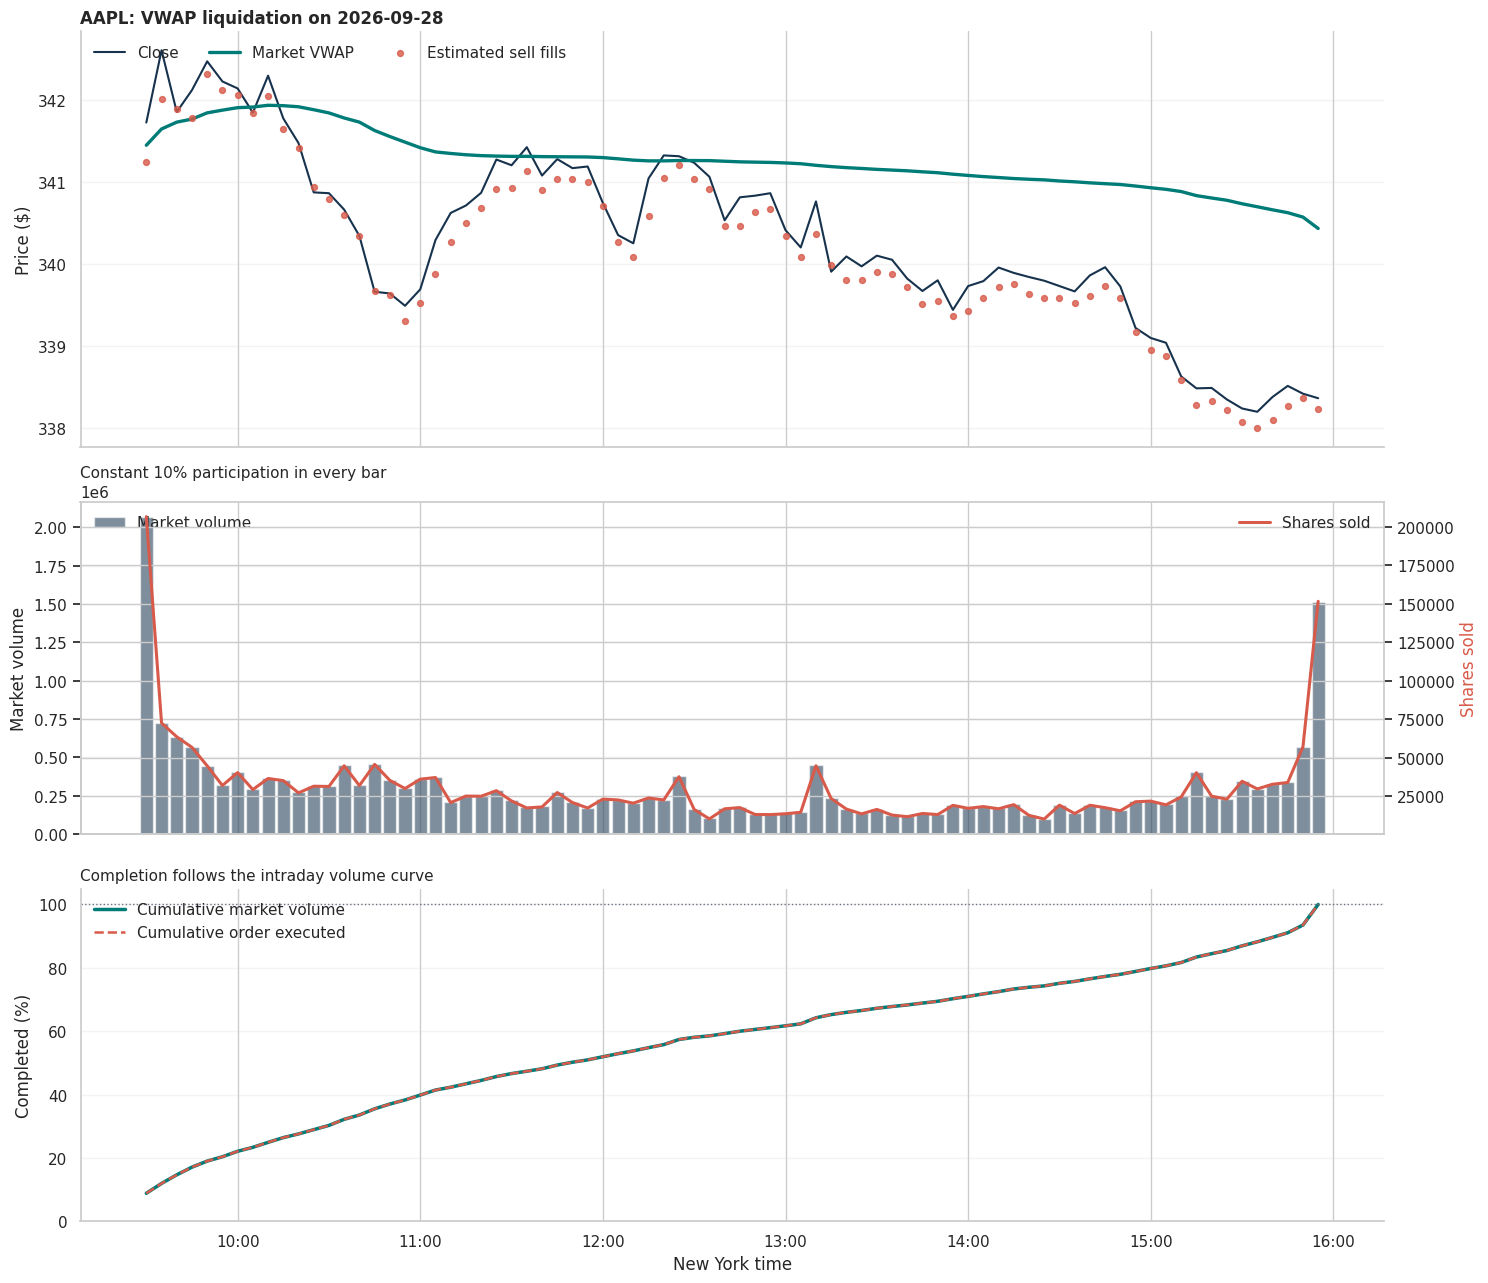

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(15, 13), sharex=True, height_ratios=[1.25, 1, 1])
fig.patch.set_facecolor('#FFFFFF')

axes[0].plot(execution.index, execution['Close'], color=COLORS['navy'], linewidth=1.5, label='Close')
axes[0].plot(execution.index, execution['market_vwap'], color=COLORS['teal'], linewidth=2.4, label='Market VWAP')
axes[0].scatter(execution.index, execution['estimated_fill_price'], s=18, color=COLORS['coral'], alpha=0.8, label='Estimated sell fills', zorder=3)
axes[0].set_ylabel('Price ($)')
axes[0].set_title(f'{TICKER}: VWAP liquidation on {session_date}', loc='left', fontweight='bold')
axes[0].legend(ncol=3, frameon=False, loc='upper left')

axes[1].bar(execution.index, execution['Volume'], width=0.003, color=COLORS['navy'], alpha=0.55, label='Market volume')
volume_axis = axes[1].twinx()
volume_axis.plot(execution.index, execution['executed_shares'], color=COLORS['coral'], linewidth=2.2, label='Shares sold')
axes[1].set_ylabel('Market volume')
volume_axis.set_ylabel('Shares sold', color=COLORS['coral'])
axes[1].set_title(f'Constant {MAX_PARTICIPATION_RATE:.0%} participation in every bar', loc='left', fontsize=11)
axes[1].legend(loc='upper left', frameon=False)
volume_axis.legend(loc='upper right', frameon=False)

axes[2].plot(execution.index, 100 * execution['cum_volume_pct'], color=COLORS['teal'], linewidth=2.5, label='Cumulative market volume')
axes[2].plot(execution.index, 100 * execution['cum_order_pct'], color=COLORS['coral'], linewidth=1.8, linestyle='--', label='Cumulative order executed')
axes[2].axhline(100, color=COLORS['gray'], linewidth=1, linestyle=':')
axes[2].set_ylim(0, 105)
axes[2].set_ylabel('Completed (%)')
axes[2].set_title('Completion follows the intraday volume curve', loc='left', fontsize=11)
axes[2].legend(frameon=False, loc='upper left')

for axis in axes:
    axis.spines[['top', 'right']].set_visible(False)
    axis.grid(axis='y', alpha=0.22)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=execution.index.tz))
axes[2].set_xlabel('New York time')
fig.tight_layout()
plt.show()


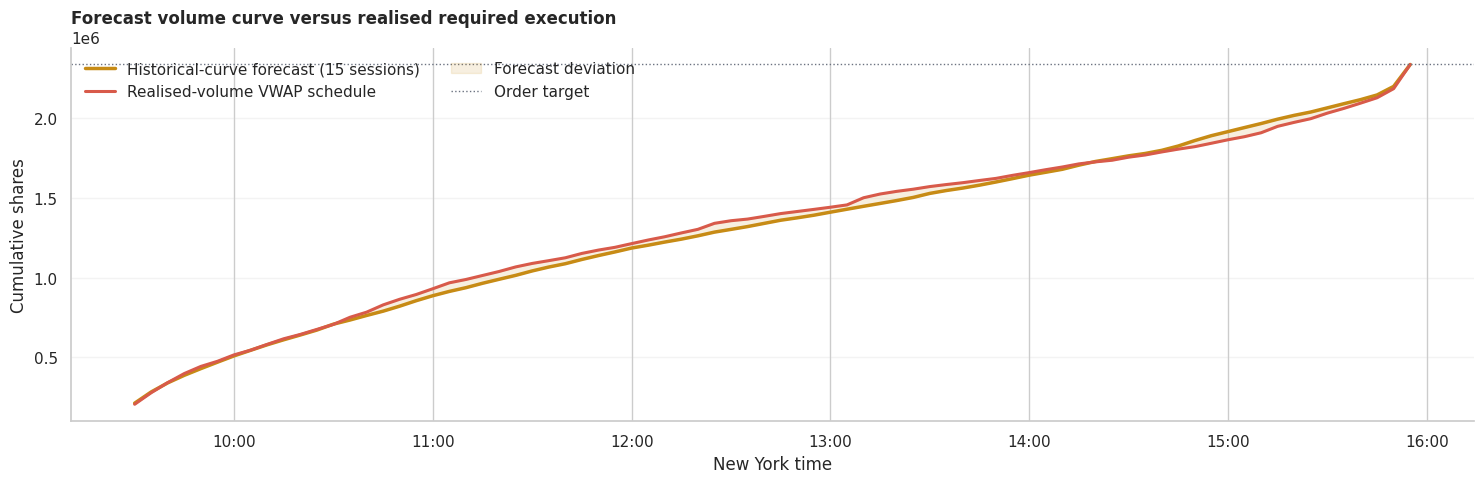

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(execution.index, execution['forecast_shares'].cumsum(), color=COLORS['gold'], linewidth=2.5, label=f'Historical-curve forecast ({len(prior_sessions)} sessions)')
ax.plot(execution.index, execution['cum_executed_shares'], color=COLORS['coral'], linewidth=2.2, label='Realised-volume VWAP schedule')
ax.fill_between(execution.index, execution['forecast_shares'].cumsum(), execution['cum_executed_shares'], color=COLORS['gold'], alpha=0.13, label='Forecast deviation')
ax.axhline(metrics['Order shares'], color=COLORS['gray'], linewidth=1, linestyle=':', label='Order target')
ax.set_title('Forecast volume curve versus realised required execution', loc='left', fontweight='bold')
ax.set_ylabel('Cumulative shares')
ax.set_xlabel('New York time')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=execution.index.tz))
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.22)
ax.legend(ncol=2, frameon=False, loc='upper left')
fig.tight_layout()
plt.show()


## What this means for a 10% daily-volume sale

- **Order size:** sell `10% x expected daily volume`.
- **Distribution:** trade `10% x expected bar volume` in each 5-minute bar. This naturally trades more near the open and close when the stock's volume is usually higher.
- **Before trading:** use the historical volume curve (gold line) to stage child orders.
- **During trading:** continuously compare realised volume with the forecast. With a hard 10% cap and a 10%-of-volume order, falling behind cannot be recovered without breaking the cap. In production, choose a lower target participation rate, allow a higher catch-up cap, or accept partial completion.
- **Caution:** `yfinance` bars and the impact model are research inputs, not executable quotes. A production algorithm also needs live volume, spread, volatility, order-book, auction, and venue data.

In [ ]:
# Inspect the child-order schedule sent to the market.
schedule_columns = ['Volume', 'forecast_shares', 'target_shares', 'executed_shares', 'participation_rate', 'estimated_fill_price', 'cum_order_pct']
schedule = execution.loc[:, schedule_columns].rename(columns={
    'Volume': 'market_volume',
    'forecast_shares': 'forecast_child_order',
    'target_shares': 'realised_vwap_child_order',
    'executed_shares': 'shares_sold',
    'participation_rate': 'participation',
    'estimated_fill_price': 'estimated_sell_price',
    'cum_order_pct': 'order_complete',
}).round(4)
schedule


Price,market_volume,forecast_child_order,realised_vwap_child_order,shares_sold,participation,estimated_sell_price,order_complete
Datetime,,,,,,,
2026-09-28 09:30:00-04:00,2063700,"213,127.35","206,370.00","206,370.00",0.10,341.24,0.09
2026-09-28 09:35:00-04:00,725015,"70,633.69","72,501.50","72,501.50",0.10,342.00,0.12
2026-09-28 09:40:00-04:00,635548,"56,927.36","63,554.80","63,554.80",0.10,341.88,0.15
2026-09-28 09:45:00-04:00,567063,"47,348.82","56,706.30","56,706.30",0.10,341.78,0.17
2026-09-28 09:50:00-04:00,446735,"41,950.55","44,673.50","44,673.50",0.10,342.31,0.19
...,...,...,...,...,...,...,...
2026-09-28 15:35:00-04:00,297348,"26,089.78","29,734.80","29,734.80",0.10,338.00,0.88
2026-09-28 15:40:00-04:00,327638,"25,294.93","32,763.80","32,763.80",0.10,338.10,0.90
2026-09-28 15:45:00-04:00,339137,"29,460.08","33,913.70","33,913.70",0.10,338.27,0.91
